In [1]:
#Importing the Libraries
#!pip uninstall numpy
#!pip uninstall tensorflow
#!pip uninstall scipy

In [2]:
#Importing the Libraries/ packages
!pip install "numpy<1.27" --upgrade
!pip install tensorflow
!pip install wordcloud
import pandas as pd
from pandas import Series,DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,Flatten,GlobalAveragePooling1D,Bidirectional
from tensorflow.keras.preprocessing .text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download("stopwords")
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("punkt")
from wordcloud  import WordCloud,STOPWORDS, ImageColorGenerator
from PIL import Image
import re
from collections import Counter

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    warnings.filterwarnings("ignore")
import os
import datetime
import random
    


C:\Users\beatr\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.12.2 when it was built against 1.12.1, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\beatr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\beatr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\beatr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:

#Downloaded the files from 

In [4]:

#Dataset Information
#Additional Information

#This dataset was created for the Paper 'From Group to Individual Labels using Deep Features', Kotzias et. al,. KDD 2015
#Please cite the paper if you want to use it :)

#It contains sentences labelled with positive or negative sentiment.

#=======
#Format:
#=======
#sentence 	 score 

#=======
#Details:
#=======
#Score is either 1 (for positive) or 0 (for negative)	
#The sentences come from three different websites/fields:

#imdb.com
#amazon.com
#yelp.com




In [5]:
##Loading the data
#defining  the file path
Local_path = 'C:/Users/beatr/OneDrive/Desktop/WGU/D213/Task2/Data/sentiment labelled sentences/'
#Input data
InputFilePath_imdb = Local_path + 'imdb_labelled.txt'
InputFilePath_amazon = Local_path + 'amazon_cells_labelled.txt'
InputFilePath_yelp = Local_path + 'yelp_labelled.txt'
#Output data 
CleanedFilePath= Local_path + 'Sentiment_cleaned_data.txt'
X_TrainedDataFilePath= Local_path + 'X_Train_data.txt'
X_TestDataFilePath= Local_path + 'X_Test_data.txt'
y_TrainedDataFilePath= Local_path + 'Y_Train_data.txt'
y_TestDataFilePath= Local_path + 'y_Test_data.txt'

# loading the data files
amazon_df = pd.read_csv(InputFilePath_amazon, sep="\t", header=None, names=["text","Rating"])  
print(amazon_df.shape)
#print(amazon_df.head())
imdb_df = pd.read_csv(InputFilePath_imdb, sep="\t", header=None, names=["text","Rating"])
print(imdb_df.shape)
#print(imdb_df.head())
yelp_df = pd.read_csv(InputFilePath_yelp, sep="\t", header=None, names=["text","Rating"]) 
print(yelp_df.shape)
#print(yelp_df.head())


(1000, 2)
(748, 2)
(1000, 2)


In [6]:
#Merging data files - Amazon, imdb, yelp
Sentiment_df= pd.concat((amazon_df,imdb_df,yelp_df),ignore_index=True)

In [7]:
#Data Exploration
Sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2748 non-null   object
 1   Rating  2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [8]:
Sentiment_df.shape

(2748, 2)

In [9]:
pd.set_option("display.max_colwidth", None)
Sentiment_df.head()

,text,Rating
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0
4,The mic is great.,1


In [10]:
#Viewing the sentiments
Sentiment_df['Rating'].value_counts()
#Score is either 1 (for positive) or 0 (for negative)

Rating
1    1386
0    1362
Name: count, dtype: int64

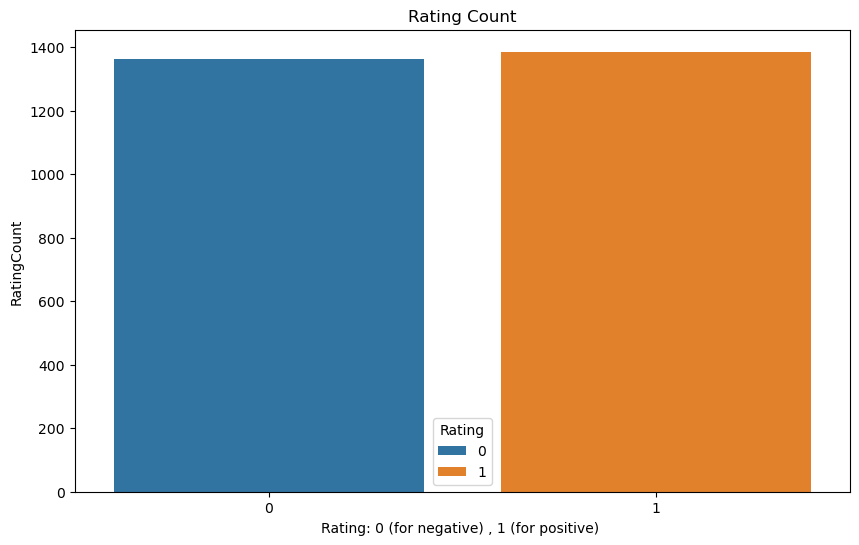

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=Sentiment_df, x='Rating', hue='Rating')
plt.title('Rating Count')
plt.xlabel('Rating: 0 (for negative) , 1 (for positive) ')
plt.ylabel('RatingCount')
plt.show()

In [12]:
#source of regex : https://pythonguides.com/check-if-a-string-is-an-emoji-in-python/

#Checking for unusual characters (e.g., emojis, non-English characters)
#Removing nulls from the data frame and 
texts = Sentiment_df["text"].dropna().astype(str).tolist()


# Regex for emojis
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # identify emojis/emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F700-\U0001F77F"  # alchemical symbols
    u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
    u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
    u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
    u"\U0001FA00-\U0001FA6F"  # Chess Symbols
    u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A                   
    u"\U0001F1E0-\U0001F1FF"  # flags
"]+", flags=re.UNICODE)
# Count emojis
emoji_count = sum(len(emoji_pattern.findall(t)) for t in texts)

# Count non-ASCII characters (anything beyond standard English letters & punctuation)
non_ascii_chars = Counter(ch for t in texts for ch in t if ord(ch) > 127)

print("Total emoji occurrences:", emoji_count)
print("Top 15 unusual characters:", non_ascii_chars.most_common(20))


Total emoji occurrences: 0
Top 15 unusual characters: [('é', 7), ('\x96', 5), ('\x85', 2), ('å', 1), ('\x97', 1), ('ê', 1)]


In [13]:
#Checking for Nulls and missing data

print(Sentiment_df[Sentiment_df[Sentiment_df.columns[Sentiment_df.isna().any()]].columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Empty DataFrame
None


In [14]:
#Dropping missing values
Sentiment_df=Sentiment_df.dropna()

In [15]:
#vocabulary size
#Getting the total number of words and characters
Sentiment_df['total Words']=[len(x.split())for x in Sentiment_df['text'].tolist()]
#Sentiment_df['total chars']=Sentiment_df.apply(len)
Sentiment_df

,text,Rating,total Words
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,21
1,"Good case, Excellent value.",1,4
2,Great for the jawbone.,1,4
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,11
4,The mic is great.,1,4
...,...,...,...
2743,I think food should have flavor and texture and both were lacking.,0,12
2744,Appetite instantly gone.,0,3
2745,Overall I was not impressed and would not go back.,0,10
2746,"The whole experience was underwhelming, and I think we'll just go to Ninja Sushi next time.",0,16


In [16]:
#Length review  on the original dataset
text_length = Sentiment_df.text.str.len()
type(text_length)
mean_length = Sentiment_df.text.str.len().mean()
print(f"The mean text Length is: {mean_length} ")
max_length = Sentiment_df.text.str.len().max()
print(f"The Maximum text Length is: {max_length} ")
Min_length = Sentiment_df.text.str.len().min()
print(f"The minimum text Length is: {Min_length} ")


The mean text Length is: 71.52838427947599 
The Maximum text Length is: 7944 
The minimum text Length is: 7 


In [17]:
#Data Cleaning

In [18]:
#Removing URL's and email addresses

Sentiment_df["text"] = Sentiment_df["text"].replace(r"https?://\S+|www\.\S+|\S+@\S+", " ", regex=True)
pd.set_option("display.max_colwidth", None)
Sentiment_df.head()

,text,Rating,total Words
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,21
1,"Good case, Excellent value.",1,4
2,Great for the jawbone.,1,4
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,11
4,The mic is great.,1,4


In [19]:

#Converting to lower case
Sentiment_df["text"] = Sentiment_df["text"].str.lower()
pd.set_option("display.max_colwidth", None)
Sentiment_df.head()


,text,Rating,total Words
0,so there is no way for me to plug it in here in the us unless i go by a converter.,0,21
1,"good case, excellent value.",1,4
2,great for the jawbone.,1,4
3,tied to charger for conversations lasting more than 45 minutes.major problems!!,0,11
4,the mic is great.,1,4


In [20]:
#Remove Punctuations.. leave letters, numbers and spaces
Sentiment_df["text"]= Sentiment_df["text"].replace(r"[^a-z0-9\s']", " ", regex=True)
pd.set_option("display.max_colwidth", None)
Sentiment_df.head()

,text,Rating,total Words
0,so there is no way for me to plug it in here in the us unless i go by a converter,0,21
1,good case excellent value,1,4
2,great for the jawbone,1,4
3,tied to charger for conversations lasting more than 45 minutes major problems,0,11
4,the mic is great,1,4


In [21]:
#Removing extra spaces, trailing and leading spaces
Sentiment_df["text"]= Sentiment_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
pd.set_option("display.max_colwidth", None)
Sentiment_df.head()

,text,Rating,total Words
0,so there is no way for me to plug it in here in the us unless i go by a converter,0,21
1,good case excellent value,1,4
2,great for the jawbone,1,4
3,tied to charger for conversations lasting more than 45 minutes major problems,0,11
4,the mic is great,1,4


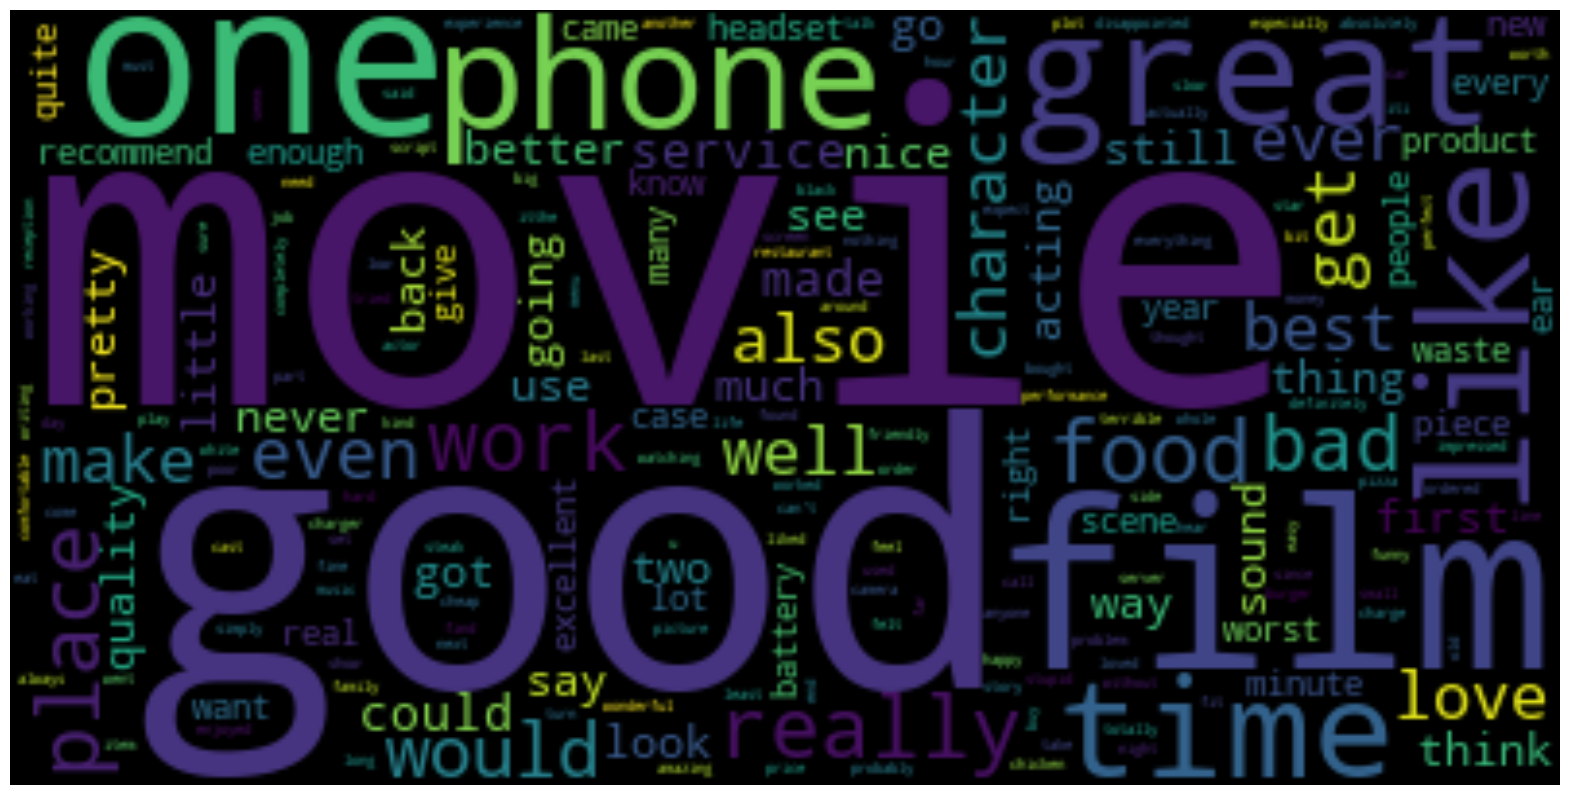

In [22]:
#creating a word cloud of the frequently used words
stop_words = set(stopwords.words("english"))
plt.figure(figsize=(20, 15))
FrequentText= "".join(review for review in Sentiment_df.text)
wordcloud= WordCloud(stopwords=stop_words).generate(FrequentText)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()





    

In [23]:
#Removing stop words

#stop_words = set(stopwords.words("english"))

Sentiment_df["text"] = Sentiment_df["text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words]))
    
 
    
pd.set_option("display.max_colwidth", None)  
pd.set_option('display.max_columns', None)
print(Sentiment_df.head())


                                                           text  Rating  \
0                               way plug us unless go converter       0   
1                                     good case excellent value       1   
2                                                 great jawbone       1   
3  tied charger conversations lasting 45 minutes major problems       0   
4                                                     mic great       1   

   total Words  
0           21  
1            4  
2            4  
3           11  
4            4  


In [24]:
#Finding the vocabulary
Sentiment_reviews = Sentiment_df['text'].tolist()
vocabulary = set()
max_review_len = 0

for review in Sentiment_reviews:
    words = review.split()
    max_review_len = max(max_review_len, len(words))
    vocabulary.update(words)
vocab_size = len(vocabulary)

print("Vocabulary Size: ", vocab_size)
print("Longest Review Length: ", max_review_len)


Vocabulary Size:  5113
Longest Review Length:  785


In [25]:
#Finding the word embedding length

embedding_size = int(np.log2(vocab_size) * 10)
print("Embedding Size: ", embedding_size)

Embedding Size:  123


In [26]:
# Word Tokenization
#Word Tokenization is the process of splitting text into smaller pieces or tokens.This enables NLP to be able to analyse text data
# Word Tokenization of the data

Sentiment_df["text_tokenized"] = Sentiment_df["text"].apply(word_tokenize)

#Stemming and Lemmatizing(Matching words)
#Stemming is a text pre-processing technique in NLP that reduces words to their root formby removing prefixes and suffixes
#Lematization uses linguistics dictionary, rules amd part of speech tags to return avtual valid word
#Steming is faster , rule based but it cab produce weierd non-words
#Lemati#zation is slower but gives better words for readability and analysis


#Lemmatization of the data

lemmatizer = WordNetLemmatizer()
Sentiment_df["text_lemmatized"] = Sentiment_df["text_tokenized"].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x]))

pd.set_option("display.max_colwidth", None)
Sentiment_df.head()

,text,Rating,total Words,text_tokenized,text_lemmatized
0,way plug us unless go converter,0,21,"[way, plug, us, unless, go, converter]",way plug u unless go converter
1,good case excellent value,1,4,"[good, case, excellent, value]",good case excellent value
2,great jawbone,1,4,"[great, jawbone]",great jawbone
3,tied charger conversations lasting 45 minutes major problems,0,11,"[tied, charger, conversations, lasting, 45, minutes, major, problems]",tied charger conversation lasting 45 minute major problem
4,mic great,1,4,"[mic, great]",mic great


In [27]:
#Tokenize the text into individual words 
tokenizer =Tokenizer()
tokenizer.fit_on_texts(Sentiment_df["text_lemmatized"])
Sentiment_df["text_sequence"] = tokenizer.texts_to_sequences(Sentiment_df["text_lemmatized"])
Sentiment_df.head()

,text,Rating,total Words,text_tokenized,text_lemmatized,text_sequence
0,way plug us unless go converter,0,21,"[way, plug, us, unless, go, converter]",way plug u unless go converter,"[44, 252, 103, 476, 25, 2043]"
1,good case excellent value,1,4,"[good, case, excellent, value]",good case excellent value,"[1, 60, 34, 315]"
2,great jawbone,1,4,"[great, jawbone]",great jawbone,"[3, 963]"
3,tied charger conversations lasting 45 minutes major problems,0,11,"[tied, charger, conversations, lasting, 45, minutes, major, problems]",tied charger conversation lasting 45 minute major problem,"[2044, 126, 632, 964, 1326, 61, 1327, 77]"
4,mic great,1,4,"[mic, great]",mic great,"[759, 3]"


In [28]:
#The Dictionary of the original words in the text
print(tokenizer.word_index)
word_index_size= len(tokenizer.word_index)

{'good': 1, 'movie': 2, 'great': 3, 'film': 4, 'phone': 5, 'one': 6, '0': 7, '1': 8, 'time': 9, 'like': 10, "'s": 11, 'food': 12, 'place': 13, 'service': 14, 'work': 15, 'bad': 16, 'really': 17, 'well': 18, 'would': 19, 'best': 20, 'even': 21, 'ever': 22, 'also': 23, 'back': 24, 'go': 25, 'get': 26, 'quality': 27, 'love': 28, 'make': 29, 'character': 30, 'made': 31, 'product': 32, 'headset': 33, 'excellent': 34, 'sound': 35, 'could': 36, 'nice': 37, 'thing': 38, 'better': 39, 'never': 40, 'recommend': 41, 'much': 42, 'use': 43, 'way': 44, 'battery': 45, 'think': 46, 'first': 47, 'look': 48, 'price': 49, 'pretty': 50, 'see': 51, 'acting': 52, 'ear': 53, 'year': 54, 'say': 55, 'got': 56, 'worst': 57, 'still': 58, '2': 59, 'case': 60, 'minute': 61, '10': 62, 'everything': 63, 'enough': 64, 'two': 65, 'little': 66, 'disappointed': 67, 'every': 68, 'right': 69, 'going': 70, 'amazing': 71, 'scene': 72, 'waste': 73, 'people': 74, 'real': 75, 'definitely': 76, 'problem': 77, 'know': 78, 'terri

In [29]:
#

In [30]:
#Padding process
#Padding is the process of making all sequences the same length
# Set max_len to the 95th percentile
Sentiment_df["sequence_length"] = Sentiment_df["text_sequence"].apply(len)
# Obtaining the quantiles length
quantiles = Sentiment_df["sequence_length"].quantile([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
print("Sequence Length Quantiles:\n", quantiles)
#Defining the 95th quantile to be used in the padding process
max_len = int(Sentiment_df["sequence_length"].quantile(0.99))
print("95th percentile max_len:", max_len)

Sentiment_padding = pad_sequences(Sentiment_df["text_sequence"], maxlen=max_len, padding='post')
Sentiment_df["text_padded"] = list(Sentiment_padding)

print(Sentiment_df.head(1))

Sequence Length Quantiles:
 0.00      0.00
0.10      2.00
0.25      3.00
0.50      5.00
0.75      8.00
0.90     11.30
0.95     14.00
0.99     21.53
1.00    793.00
Name: sequence_length, dtype: float64
95th percentile max_len: 21
                              text  Rating  total Words  \
0  way plug us unless go converter       0           21   

                           text_tokenized                 text_lemmatized  \
0  [way, plug, us, unless, go, converter]  way plug u unless go converter   

                   text_sequence  sequence_length  \
0  [44, 252, 103, 476, 25, 2043]                6   

                                                                  text_padded  
0  [44, 252, 103, 476, 25, 2043, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  


In [31]:
print(Sentiment_padding.shape)

(2748, 21)


In [32]:
#The Dictionary of the modified words in the text
print(tokenizer.word_index)

{'good': 1, 'movie': 2, 'great': 3, 'film': 4, 'phone': 5, 'one': 6, '0': 7, '1': 8, 'time': 9, 'like': 10, "'s": 11, 'food': 12, 'place': 13, 'service': 14, 'work': 15, 'bad': 16, 'really': 17, 'well': 18, 'would': 19, 'best': 20, 'even': 21, 'ever': 22, 'also': 23, 'back': 24, 'go': 25, 'get': 26, 'quality': 27, 'love': 28, 'make': 29, 'character': 30, 'made': 31, 'product': 32, 'headset': 33, 'excellent': 34, 'sound': 35, 'could': 36, 'nice': 37, 'thing': 38, 'better': 39, 'never': 40, 'recommend': 41, 'much': 42, 'use': 43, 'way': 44, 'battery': 45, 'think': 46, 'first': 47, 'look': 48, 'price': 49, 'pretty': 50, 'see': 51, 'acting': 52, 'ear': 53, 'year': 54, 'say': 55, 'got': 56, 'worst': 57, 'still': 58, '2': 59, 'case': 60, 'minute': 61, '10': 62, 'everything': 63, 'enough': 64, 'two': 65, 'little': 66, 'disappointed': 67, 'every': 68, 'right': 69, 'going': 70, 'amazing': 71, 'scene': 72, 'waste': 73, 'people': 74, 'real': 75, 'definitely': 76, 'problem': 77, 'know': 78, 'terri

In [33]:
Sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             2748 non-null   object
 1   Rating           2748 non-null   int64 
 2   total Words      2748 non-null   int64 
 3   text_tokenized   2748 non-null   object
 4   text_lemmatized  2748 non-null   object
 5   text_sequence    2748 non-null   object
 6   sequence_length  2748 non-null   int64 
 7   text_padded      2748 non-null   object
dtypes: int64(3), object(5)
memory usage: 171.9+ KB


In [34]:
#Setting the seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

#Split data into training and testing

X = np.array(Sentiment_df["text_padded"].to_list())
y = Sentiment_df["Rating"].values
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [35]:
#Output of cleaned data, test and train data

Sentiment_df.to_csv(CleanedFilePath, index=False)
pd.DataFrame(X_train).to_csv(X_TrainedDataFilePath, index=False)
pd.DataFrame(X_test).to_csv(X_TestDataFilePath, index=False)
pd.DataFrame(y_train).to_csv(y_TrainedDataFilePath, index=False)
pd.DataFrame(y_test).to_csv(y_TestDataFilePath, index=False)

In [36]:
#Building the Neural network Model / ensuring the reproducibility of the results of the model via the seed  of 42
word_index_size = len(tokenizer.word_index) + 1
max_len = max_len
print(f"max_len:{max_len}")
model = Sequential()
model.add(Embedding(input_dim=word_index_size, output_dim=embedding_size)) #, input_length=max_len))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu",kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)))
model.add(Dropout(0.5))
model.add(Dense(32, activation="relu",kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid',kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()

max_len:21


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 21, 123)             │         574,041 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 123)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 123)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 584,090 (2.23 MB)

 Trainable params: 584,090 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#Compiling the Model/Training
total_epochs = 20
patience = max(1, int(total_epochs * 0.2))  # 20% of epochs

history=model.fit(X_train, y_train, batch_size=32, epochs=total_epochs,
          validation_split=0.3, shuffle=False,callbacks=[EarlyStopping(patience=patience , restore_best_weights=True)], 
                  verbose=True)
for i in range(len(history.history['loss'])):
    print(f"Epoch {i+1}:",
          f"accuracy={round(history.history['accuracy'][i], 4)}",
          f"loss={round(history.history['loss'][i], 2)}",
          f"val_accuracy={round(history.history['val_accuracy'][i], 4)}",
          f"val_loss={round(history.history['val_loss'][i], 4)}")

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4915 - loss: 0.6950 - val_accuracy: 0.5258 - val_loss: 0.6924
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5241 - loss: 0.6913 - val_accuracy: 0.5258 - val_loss: 0.6901
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5098 - loss: 0.6931 - val_accuracy: 0.5303 - val_loss: 0.6890
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5696 - loss: 0.6838 - val_accuracy: 0.5348 - val_loss: 0.6805
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6086 - loss: 0.6730 - val_accuracy: 0.6212 - val_loss: 0.6600
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6912 - loss: 0.6249 - val_accuracy: 0.6561 - val_loss: 0.6134
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7939 - loss: 0.5178 - val_accuracy: 0.7348 - val_loss: 0.5246
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8570 - loss: 0.3825 - val_accuracy: 0.7894 - val_loss

In [38]:
#Evaluating the performance
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7909 - loss: 0.4556 
Test Accuracy: 0.7909091114997864
Test Loss: 0.4556426703929901


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report:
               precision    recall  f1-score   support

    Negative       0.82      0.78      0.80       291
    Positive       0.76      0.81      0.78       259

    accuracy                           0.79       550
   macro avg       0.79      0.79      0.79       550
weighted avg       0.79      0.79      0.79       550



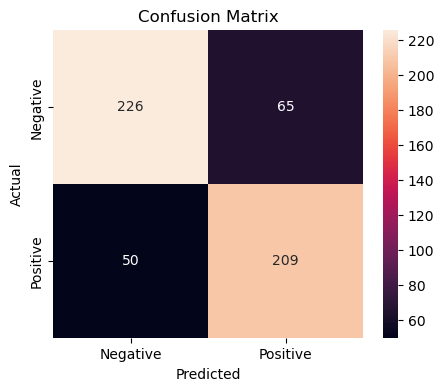

In [39]:
#Evaluating performance using a confusion matrix
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")
report = classification_report(y_test, y_pred, target_names=["Negative", "Positive"])
print("Classification Report:\n", report)
report_df = pd.DataFrame(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], output_dict=True)).transpose()
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


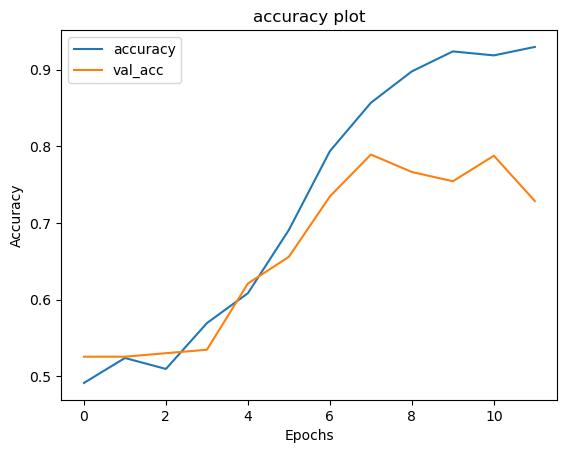

In [40]:
#Accuracy plots
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('accuracy plot')
plt.show()

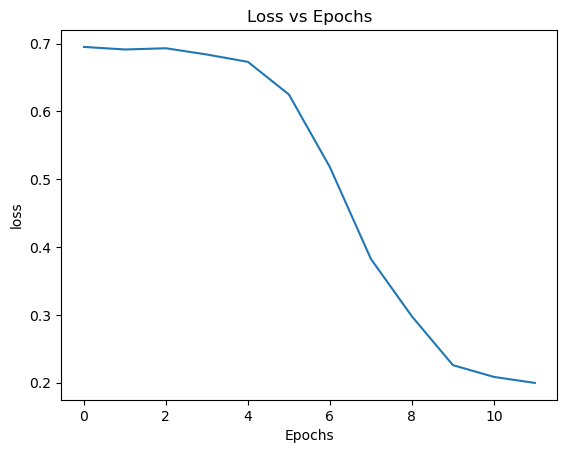

In [41]:
#Loss plot
plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Loss vs Epochs')
plt.show()